In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import plotly.graph_objects as go

In [2]:
nav = pd.read_csv('data/processed/nav_history_clean.csv', parse_dates=['date'])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

In [4]:
nav

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
...,...,...,...
45995,149324,2026-05-25,292.4810
45996,149324,2026-05-26,291.2707
45997,149324,2026-05-27,288.8007
45998,149324,2026-05-28,280.6873


In [5]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [6]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [7]:
fund_master = pd.read_csv('data/raw/01_fund_master.csv')
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [8]:
nav_with_cat = nav.merge(fund_master[['amfi_code', 'category']], on='amfi_code')

In [9]:
nav_with_cat.groupby('category')['daily_return'].std().sort_values(ascending=False)

category
Equity    0.011135
Debt      0.001775
Name: daily_return, dtype: float64

In [10]:
latest_date = nav['date'].max()
latest_date

Timestamp('2026-05-29 00:00:00')

In [11]:
def cagr_for_period(group, years_back):
    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years_back)
    if group['date'].min() > start_date:
        return None
    start_row = group[group['date'] >= start_date].sort_values('date').iloc[0]
    end_row = group[group['date'] == end_date].iloc[0]
    n_years = (end_row['date'] - start_row['date']).days / 365.25
    return (end_row['nav'] / start_row['nav']) ** (1 / n_years) - 1

In [12]:
def cagr_since_inception(group):
    start_row = group.sort_values('date').iloc[0]
    end_row = group.sort_values('date').iloc[-1]
    n_years = (end_row['date'] - start_row['date']).days / 365.25
    cagr = (end_row['nav'] / start_row['nav']) ** (1 / n_years) - 1
    return cagr, n_years

In [13]:
results = []
for code, group in nav.groupby('amfi_code'):
    since_inception_cagr, n_years = cagr_since_inception(group)
    results.append({
        'amfi_code': code,
        'return_1yr_pct': cagr_for_period(group, 1),
        'return_3yr_pct': cagr_for_period(group, 3),
        'return_since_inception_pct': since_inception_cagr,
        'since_inception_n_years': round(n_years, 2),   # e.g. 4.41 -- proves it's honest
    })

In [14]:
cagr_df = pd.DataFrame(results)
cagr_df[['return_1yr_pct', 'return_3yr_pct', 'return_since_inception_pct']] *= 100
cagr_df

,amfi_code,return_1yr_pct,return_3yr_pct,return_since_inception_pct,since_inception_n_years
0,100016,-2.225777,1.292353,2.637074,4.4
1,100025,3.707553,3.915479,4.458210,4.4
2,100033,53.277195,32.433971,30.123153,4.4
3,101206,47.963794,28.960211,23.538361,4.4
4,101207,-24.000309,-4.151454,7.938765,4.4
5,101208,7.241777,6.314299,6.509027,4.4
6,102885,20.222859,19.662361,18.232379,4.4
7,102886,-16.807960,-0.767232,1.171745,4.4
8,102887,13.593044,25.549670,16.841120,4.4
9,118632,34.007896,22.646647,24.049493,4.4


In [15]:
RISK_FREE_RATE = 0.065
TRADING_DAYS = 252
daily_rf = RISK_FREE_RATE / TRADING_DAYS

In [16]:
sharpe_results = []
for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    mean_daily_return = returns.mean()
    std_daily_return = returns.std()
    sharpe = (mean_daily_return - daily_rf) / std_daily_return * np.sqrt(TRADING_DAYS)
    sharpe_results.append({'amfi_code': code, 'sharpe_ratio': sharpe})

In [17]:
sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df['rank'] = sharpe_df['sharpe_ratio'].rank(ascending=False).astype(int)
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
sharpe_df

,amfi_code,sharpe_ratio,rank
0,148567,1.448291,1
1,120843,1.306744,2
2,148569,1.234930,3
3,119551,1.208267,4
4,120505,1.180101,5
5,149323,1.132122,6
6,100033,1.093699,7
7,118632,1.081659,8
8,101206,1.027213,9
9,120504,1.026524,10


In [18]:
sortino_results = []
for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    mean_daily_return = returns.mean()

    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()

    sortino = (mean_daily_return - daily_rf) / downside_std * np.sqrt(TRADING_DAYS)
    sortino_results.append({'amfi_code': code, 'sortino_ratio': sortino, 'n_negative_days': len(downside_returns)})

In [19]:
sortino_df = pd.DataFrame(sortino_results)
sortino_df['rank'] = sortino_df['sortino_ratio'].rank(ascending=False).astype(int)
sortino_df = sortino_df.sort_values('sortino_ratio', ascending=False).reset_index(drop=True)
sortino_df

,amfi_code,sortino_ratio,n_negative_days,rank
0,148567,2.385644,506,1
1,120843,2.364320,534,2
2,148569,2.146914,545,3
3,119551,2.140267,518,4
4,120505,2.029353,539,5
5,149323,1.875101,526,6
6,118632,1.850133,532,7
7,100033,1.829134,538,8
8,120504,1.805294,517,9
9,101206,1.799563,539,10


In [20]:
bench = pd.read_csv('data/raw/10_benchmark_indices.csv', parse_dates=['date'])
bench.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [21]:
nifty100 = bench[bench['index_name'] == 'NIFTY100'].sort_values('date').reset_index(drop=True)
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()

In [22]:
alpha_beta_results = []
for code, group in nav.groupby('amfi_code'):
    fund = group[['date', 'daily_return']].dropna()
    merged = fund.merge(nifty100[['date', 'benchmark_return']], on='date', how='inner').dropna()

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['benchmark_return'], merged['daily_return']
    )

    alpha_beta_results.append({
        'amfi_code': code,
        'beta': slope,
        'alpha_annualized_pct': intercept * 252 * 100,
        'r_squared': r_value ** 2,
        'n_obs': len(merged),
    })

In [23]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df

,amfi_code,beta,alpha_annualized_pct,r_squared,n_obs
0,100016,-0.058268,3.747581,2.665033e-03,1149
1,100025,0.001158,4.281792,1.461284e-05,1149
2,100033,0.005104,27.195355,1.206652e-05,1149
3,101206,0.021086,21.399785,3.480482e-04,1149
4,101207,-0.065289,10.897092,1.064105e-03,1149
5,101208,0.000267,6.086146,4.607624e-05,1149
6,102885,-0.019487,17.048757,3.828503e-04,1149
7,102886,-0.042125,2.896940,8.964295e-04,1149
8,102887,0.016683,16.211257,1.861917e-04,1149
9,118632,-0.008354,21.829398,5.791756e-05,1149


In [24]:
alpha_beta_df.to_csv('data/processed/alpha_beta.csv', index=False)

In [25]:
drawdown_results = []
for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date').reset_index(drop=True)

    running_max = group['nav'].cummax()
    drawdown = group['nav'] / running_max - 1

    trough_idx = drawdown.idxmin()
    trough_date = group.loc[trough_idx, 'date']
    max_dd = drawdown.loc[trough_idx]

    peak_idx = group.loc[:trough_idx, 'nav'].idxmax()
    peak_date = group.loc[peak_idx, 'date']

    drawdown_results.append({
        'amfi_code': code,
        'max_drawdown_pct': max_dd * 100,
        'peak_date': peak_date,
        'trough_date': trough_date,
    })

In [26]:
drawdown_df = pd.DataFrame(drawdown_results).sort_values('max_drawdown_pct')
drawdown_df

,amfi_code,max_drawdown_pct,peak_date,trough_date
22,119599,-52.574221,2023-01-17,2025-10-28
17,119095,-51.677754,2025-05-22,2026-05-11
4,101207,-35.446916,2024-11-21,2026-05-11
39,149324,-31.171900,2024-05-03,2025-01-03
21,119598,-28.706006,2024-08-28,2025-05-14
7,102886,-28.001124,2025-01-07,2026-04-27
0,100016,-24.734441,2022-03-30,2022-09-15
29,120842,-24.003511,2023-11-09,2024-10-17
11,118634,-23.344886,2025-04-09,2026-02-20
15,119093,-21.751396,2022-02-24,2023-05-22


In [27]:
scorecard = (
    cagr_df[['amfi_code', 'return_3yr_pct']]
    .merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code')
    .merge(alpha_beta_df[['amfi_code', 'alpha_annualized_pct']], on='amfi_code')
    .merge(drawdown_df[['amfi_code', 'max_drawdown_pct']], on='amfi_code')
    .merge(fund_master[['amfi_code', 'scheme_name', 'category', 'expense_ratio_pct']], on='amfi_code')
)

In [28]:
def pct_score(series, higher_is_better):
    r = series.rank(pct=True)
    return (r if higher_is_better else (1 - r)) * 100

scorecard['score_3yr']     = pct_score(scorecard['return_3yr_pct'], higher_is_better=True)
scorecard['score_sharpe']  = pct_score(scorecard['sharpe_ratio'], higher_is_better=True)
scorecard['score_alpha']   = pct_score(scorecard['alpha_annualized_pct'], higher_is_better=True)
scorecard['score_expense'] = pct_score(scorecard['expense_ratio_pct'], higher_is_better=False)  # genuinely inverted -- lower cost wins
scorecard['score_maxdd']   = pct_score(scorecard['max_drawdown_pct'], higher_is_better=True)      # NOT inverted -- already stored as negative, less-negative = better

scorecard['fund_scorecard'] = (
    0.30 * scorecard['score_3yr'] +
    0.25 * scorecard['score_sharpe'] +
    0.20 * scorecard['score_alpha'] +
    0.15 * scorecard['score_expense'] +
    0.10 * scorecard['score_maxdd']
)

In [29]:
scorecard = scorecard.sort_values('fund_scorecard', ascending=False).reset_index(drop=True)
scorecard[['amfi_code', 'scheme_name', 'category', 'fund_scorecard']]

,amfi_code,scheme_name,category,fund_scorecard
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,85.8750
1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,81.8750
2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,81.6250
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,80.3750
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,79.6250
5,119094,Axis Midcap Fund - Regular - Growth,Equity,76.6250
6,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,74.4375
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,73.3125
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,67.8125
9,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,67.0000


In [30]:
scorecard.to_csv('data/processed/fund_scorecard.csv', index=False)

In [31]:
n50 = bench[bench['index_name'] == 'NIFTY50'].sort_values('date').reset_index(drop=True)
n50['benchmark_return'] = n50['close_value'].pct_change()

In [32]:
n100 = bench[bench['index_name'] == 'NIFTY100'].sort_values('date').reset_index(drop=True)
n100['benchmark_return'] = n100['close_value'].pct_change()

In [33]:
top5 = [148567, 120505, 120843, 100033, 120504]
end_date = nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)

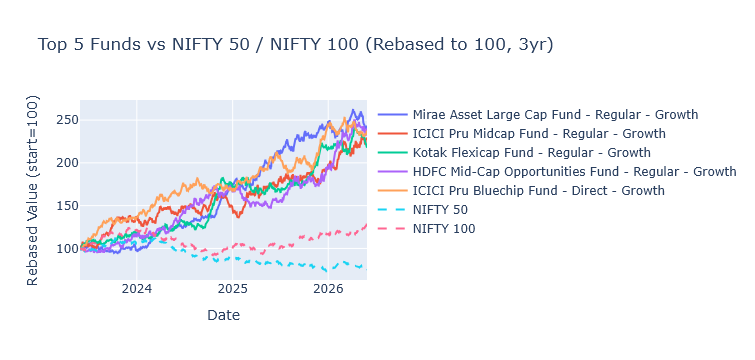

In [34]:
fig = go.Figure()
for code in top5:
    f = nav[(nav['amfi_code'] == code) & (nav['date'] >= start_date)].sort_values('date')
    rebased = f['nav'] / f['nav'].iloc[0] * 100
    name = fund_master.loc[fund_master['amfi_code'] == code, 'scheme_name'].iloc[0]
    fig.add_trace(go.Scatter(x=f['date'], y=rebased, mode='lines', name=name))

for label, b in [('NIFTY 50', n50), ('NIFTY 100', n100)]:
    bf = b[b['date'] >= start_date].sort_values('date')
    rebased = bf['close_value'] / bf['close_value'].iloc[0] * 100
    fig.add_trace(go.Scatter(x=bf['date'], y=rebased, mode='lines', name=label,
                              line=dict(dash='dash', width=2)))

fig.update_layout(title='Top 5 Funds vs NIFTY 50 / NIFTY 100 (Rebased to 100, 3yr)',
                   xaxis_title='Date', yaxis_title='Rebased Value (start=100)')
fig.show()
fig.write_image('charts/benchmark_comparison.png')

In [35]:
tracking_error_results = []
for code in top5:
    f = nav[nav['amfi_code'] == code][['date', 'daily_return']].dropna()
    row = {'amfi_code': code}
    for label, b in [('nifty50', n50), ('nifty100', n100)]:
        merged = f.merge(b[['date', 'benchmark_return']], on='date', how='inner').dropna()
        te = (merged['daily_return'] - merged['benchmark_return']).std() * np.sqrt(252)
        row[f'tracking_error_{label}_pct'] = te * 100
    tracking_error_results.append(row)

te_df = pd.DataFrame(tracking_error_results)
te_df

,amfi_code,tracking_error_nifty50_pct,tracking_error_nifty100_pct
0,148567,19.399579,18.966368
1,120505,23.312358,23.196751
2,120843,20.514777,20.642497
3,100033,22.975511,22.869942
4,120504,19.137582,19.158700
